In [1]:
import xarray as xr
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import matplotlib as mpl 
from cartopy.util import add_cyclic_point
from scipy import stats
from matplotlib.colors import LinearSegmentedColormap, Normalize
import matplotlib.patheffects as pe
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import glob


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
def global_mean_xarray(ds_XXLL):
    """ 
    Compute the global mean value of the data.
    The data has to have the lat and lon in its dimensions.
    Should not include NaN in Inputs.
    
    Parameters
    ----------
    ds_XXLL   : xarray with lat and lon. ds_XXLL.lat will be 
                used for area weight.

    Returns
    ----------
    tmp_XX    : xarray without lat and lon.
    
    """
    lat = ds_XXLL.coords['lat']        # readin lat
    # global mean
    # compute cos(lat) as a weight function
    weight_lat = np.cos(np.deg2rad(lat))/np.mean(np.cos(np.deg2rad(lat)))
    tmp_XXL = ds_XXLL.mean(dim=['lon'])*weight_lat
    tmp_XX  = tmp_XXL.mean(dim=['lat'])
    return tmp_XX

def weighted_temporal_mean_l(ds, var=None):
    """
    weight by days in each month
    """
    #ds = xr.decode_cf(ds)
    # Determine the month length
    month_length = ds.time.dt.days_in_month

    # Calculate the weights
    wgts = month_length.groupby("time.year") / month_length.groupby("time.year").sum()

    # Make sure the weights in each year add up to 1
    np.testing.assert_allclose(wgts.groupby("time.year").sum(xr.ALL_DIMS), 1.0)

    # Subset our dataset for our variable
    obs = ds if var is None else ds[var]

    # Setup our masking for nan values
    cond = obs.isnull()
    ones = xr.where(cond, 0.0, 1.0)

    # Calculate the numerator
    obs_sum = (obs * wgts).resample(time="AS").sum(dim="time")

    # Calculate the denominator
    ones_out = (ones * wgts).resample(time="AS").sum(dim="time")

    # Return the weighted average
    return obs_sum / ones_out

def daily_to_monthly_mean(da: xr.DataArray) -> xr.DataArray:
    """
    Convert daily data to monthly means by averaging daily values.
    Works with datetime64 and CFTimeIndex, and with any time-like coord name
    (e.g., 'time', 't', 'Time', etc.).
    """
    # --- find the time-like coordinate name
    time_name = None
    for name in da.coords:
        # prefer coords that are also dimensions
        if name in da.dims:
            idx = da.indexes.get(name, None)
            if isinstance(idx, (pd.DatetimeIndex, CFTimeIndex)):
                time_name = name
                break
    if time_name is None:
        # fallback: try any coord with .dt.month working
        for name in da.coords:
            try:
                _ = da[name].dt.month
                time_name = name
                break
            except Exception:
                pass
    if time_name is None:
        raise ValueError("Could not find a datetime-like coordinate to resample on.")

    # --- daily → monthly (simple mean of days; NaN-safe)
    num = da.fillna(0).resample({time_name: "MS"}).sum()
    denom = xr.where(np.isnan(da), 0.0, 1.0).resample({time_name: "MS"}).sum()
    return xr.where(denom > 0, num / denom, np.nan)

def weighted_temporal_mean_m(ds, var=None):
    """
    Convert daily data to monthly means, weighted by the number of days in each month.
    Handles missing values consistently.
    """
    # Determine the number of days in each month
    month_length = ds.time.dt.days_in_month

    # Compute weights normalized within each (year, month)
    wgts = month_length.groupby("time.month") / month_length.groupby("time.month").sum()

    # Subset to variable if provided
    obs = ds if var is None else ds[var]

    # Mask for NaNs
    cond = obs.isnull()
    ones = xr.where(cond, 0.0, 1.0)

    # Weighted sum and normalization by valid weights
    obs_sum = (obs * wgts).resample(time="MS").sum(dim="time")
    ones_out = (ones * wgts).resample(time="MS").sum(dim="time")

    # Return weighted monthly mean
    return obs_sum / ones_out

In [4]:
# CESM ARISE-SAI-1.5
num_ensembles = 10
var_list = 'TREFHT PRECT'.split()
cesm_arise_ens = {var: [] for var in var_list}

for i in range(1, num_ensembles + 1):
    ensemble_id = f'{(i):03d}' 
    print(f'Loading ensemble member {ensemble_id}')
    for var in var_list:
        file_path_arise = f'/glade/campaign/cesm/collections/ARISE-SAI-1.5/b.e21.BW.f09_g17.SSP245-TSMLT-GAUSS-DEFAULT.{ensemble_id}/atm/proc/tseries/month_1/b.e21.BW.f09_g17.SSP245-TSMLT-GAUSS-DEFAULT.{ensemble_id}.cam.h0.{var}.*.nc'
        ds_arise = xr.open_mfdataset(file_path_arise, parallel=True, combine='by_coords')

        if var == "PRECT":
            ds_arise[var] = ds_arise[var] * 1000 * 86400
            ds_arise[var].attrs.update({'units': 'mm/day', 'long_name': 'Precipitation rate'})

        cesm_arise_ens[var].append(ds_arise[var].sel(time=slice("2035-01-01", "2069-12-31")))

num_ensembles = 5
cesm_10ssp_ens = {var: [] for var in var_list}

for i in range(1, num_ensembles + 1):
    ensemble_id = f'{(i+5):03d}' 
    print(f'Loading ensemble member {ensemble_id}')
    for var in var_list:
        file_path_ssp   = f'/glade/campaign/collections/gdex/data/d651045/CESM2-WACCM-SSP245/b.e21.BWSSP245cmip6.f09_g17.CMIP6-SSP2-4.5-WACCM.{ensemble_id}/atm/proc/tseries/month_1/b.e21.BWSSP245cmip6.f09_g17.CMIP6-SSP2-4.5-WACCM.{ensemble_id}.cam.h0.{var}.*.nc'
        ds_ssp   = xr.open_mfdataset(file_path_ssp,   parallel=True, combine='by_coords')

        if var == "PRECT":
            ds_ssp[var]   = ds_ssp[var]   * 1000 * 86400
            ds_ssp[var].attrs.update({'units': 'mm/day', 'long_name': 'Precipitation rate'})
        cesm_10ssp_ens[var].append(ds_ssp[var])


cesm_arise_avg = {}
for var in var_list:
    # Concatenate all ensemble members along a new dimension
    combined = xr.concat(cesm_arise_ens[var], dim='ensemble')
    # Calculate the mean over the ensemble dimension
    cesm_arise_avg[var] = (combined.mean(dim='ensemble'))

cesm_10ssp_avg = {}
for var in var_list:
    # Concatenate all ensemble members along a new dimension
    combined = xr.concat(cesm_10ssp_ens[var], dim='ensemble')
    # Calculate the mean over the ensemble dimension
    cesm_10ssp_avg[var] = (combined.mean(dim='ensemble'))

Loading ensemble member 001
Loading ensemble member 002
Loading ensemble member 003
Loading ensemble member 004
Loading ensemble member 005
Loading ensemble member 006
Loading ensemble member 007
Loading ensemble member 008
Loading ensemble member 009
Loading ensemble member 010
Loading ensemble member 006
Loading ensemble member 007
Loading ensemble member 008
Loading ensemble member 009
Loading ensemble member 010


In [5]:
#CESM G6
num_ensembles = 3
var_list = 'TREFHT PRECT'.split()
cesm_g6_ens = {var: [] for var in var_list}
for i in range(1, num_ensembles + 1):
    ensemble_id = f'{i:03d}'  # Format ensemble number as 001, 002, ..., 010
    print(f'Loading ensemble member {ensemble_id}')
    
    for var in var_list:
        if var == 'PRECT':
            #file_path = f'/glade/campaign/cesm/collections/ARISE-SAI-1.5/b.e21.BW.f09_g17.SSP245-G6-1p5K-SAI.{ensemble_id}/atm/proc/tseries/month_1/b.e21.BW.f09_g17.SSP245-G6-1p5K-SAI.{ensemble_id}.cam.h0.{var}.*.nc'
            file_path = f'/glade/derecho/scratch/cindywang625/other_models/CESM/G6-1.5K-SAI/PRECT/CESM_b.e21.BW.f09_g17.SSP245-G6-1p5K-SAI.{ensemble_id}.cam.h0.PRECT.203501-208412.nc'
            ds = xr.open_mfdataset(file_path, parallel=True, combine='nested', concat_dim='time')
            ds = ds.sel(time=~ds.get_index("time").duplicated())
            ds[var] = ds[var] * 1000 * 86400
            ds[var].attrs.update({
    'units': 'mm/day',
})
            cesm_g6_ens[var].append((ds[var]).sel(time=slice("2035-01-01", "2084-12-31")))#*np.round(land_mask['LANDFRAC'][0]))
        else:
            #file_path = f'/glade/campaign/cesm/collections/ARISE-SAI-1.5/b.e21.BW.f09_g17.SSP245-G6-1p5K-SAI.{ensemble_id}/atm/proc/tseries/month_1/b.e21.BW.f09_g17.SSP245-G6-1p5K-SAI.{ensemble_id}.cam.h0.{var}.*.nc'
            file_path = f'/glade/derecho/scratch/cindywang625/other_models/CESM/G6-1.5K-SAI/TREFHT/CESM_b.e21.BW.f09_g17.SSP245-G6-1p5K-SAI.{ensemble_id}.cam.h0.TREFHT.203501-208412.nc'
            ds = xr.open_mfdataset(file_path, parallel=True, combine='nested', concat_dim='time')
            ds = ds.sel(time=~ds.get_index("time").duplicated())
            cesm_g6_ens[var].append((ds[var]).sel(time=slice("2035-01-01", "2084-12-31")))#*np.round(land_mask['LANDFRAC'][0]))


num_ensembles = 5
cesm_ssp_ens = {var: [] for var in var_list}
for i in range(1, num_ensembles + 1):
    ensemble_id = f'{(i):03d}'  # Format ensemble number as 001, 002, ..., 010
    print(f'Loading ensemble member {ensemble_id}')
    
    for var in var_list:
        if var == 'PRECT':
            #file_path = f'/glade/campaign/cesm/collections/CESM2-WACCM-SSP245/b.e21.BWSSP245cmip6.f09_g17.CMIP6-SSP2-4.5-WACCM.{ensemble_id}/atm/proc/tseries/month_1/b.e21.BWSSP245cmip6.f09_g17.CMIP6-SSP2-4.5-WACCM.{ensemble_id}.cam.h0.{var}.*.nc'
            file_path = f'/glade/derecho/scratch/cindywang625/other_models/CESM/SSP2-4.5/PRECT/CESM_b.e21.BWSSP245cmip6.f09_g17.CMIP6-SSP2-4.5-WACCM.{ensemble_id}.cam.h0.PRECT.201501-210012.nc'        
            ds = xr.open_mfdataset(file_path, parallel=True, combine='nested', concat_dim='time')
            ds = ds.sel(time=~ds.get_index("time").duplicated())
            ds[var] = ds[var] * 1000 * 86400
            ds[var].attrs.update({
                'units': 'mm/day',
            })
            cesm_ssp_ens[var].append((ds[var]))#*np.round(land_mask['LANDFRAC'][0]))
        else:
            #file_path = f'/glade/campaign/cesm/collections/CESM2-WACCM-SSP245/b.e21.BWSSP245cmip6.f09_g17.CMIP6-SSP2-4.5-WACCM.{ensemble_id}/atm/proc/tseries/month_1/b.e21.BWSSP245cmip6.f09_g17.CMIP6-SSP2-4.5-WACCM.{ensemble_id}.cam.h0.{var}.*.nc'
            file_path = f'/glade/derecho/scratch/cindywang625/other_models/CESM/SSP2-4.5/TREFHT/CESM_b.e21.BWSSP245cmip6.f09_g17.CMIP6-SSP2-4.5-WACCM.{ensemble_id}.cam.h0.TREFHT.201501-210012.nc'
            ds = xr.open_mfdataset(file_path, parallel=True, combine='nested', concat_dim='time')
            ds = ds.sel(time=~ds.get_index("time").duplicated())
            cesm_ssp_ens[var].append((ds[var]))#*np.round(land_mask['LANDFRAC'][0]))

cesm_g6_ens_avg = {}
for var in var_list:
    combined = xr.concat(cesm_g6_ens[var], dim='ensemble')
    cesm_g6_ens_avg[var] = combined.mean(dim='ensemble')

cesm_ssp_ens_avg = {}
for var in var_list:
    combined = xr.concat(cesm_ssp_ens[var], dim='ensemble')
    cesm_ssp_ens_avg[var] = combined.mean(dim='ensemble')

Loading ensemble member 001
Loading ensemble member 002
Loading ensemble member 003
Loading ensemble member 001
Loading ensemble member 002
Loading ensemble member 003
Loading ensemble member 004
Loading ensemble member 005


In [6]:
# MIROC G6-1.5K-SAI
num_ensembles = 10
miroc_g6_ens = {var: [] for var in var_list}
for i in range(1, num_ensembles + 1):
    ensemble_id = f'{i:02d}'  # Format ensemble number as 001, 002, ..., 010
    print(f'Loading ensemble member {ensemble_id}')
    
    for var in var_list:
        if var == 'PRECT':
            file_path = f'/glade/derecho/scratch/cindywang625/other_models/MIROC/G6-1.5K-SAI/monthly/PRECT/MIROC_P_G6-1.5K-SAI_r{ensemble_id}.nc' #g6            
            ds = xr.open_mfdataset(file_path, parallel=True, combine='nested', concat_dim='time')
            ds = ds.sel(time=~ds.get_index("time").duplicated())
            ds['P'] = ds['P'] * 86400
            ds['P'].attrs.update({
                'units': 'mm/day',
            })
            miroc_g6_ens[var].append((ds['P']).sel(time=slice("2035-01-01", "2069-12-31")))#*land_masp)
        else:
            file_path = f'/glade/derecho/scratch/cindywang625/other_models/MIROC/G6-1.5K-SAI/monthly/TREFHT/MIROC_SurfT_G6-1.5K-SAI_r{ensemble_id}.nc' #g6
            ds = xr.open_mfdataset(file_path, parallel=True, combine='nested', concat_dim='time')
            ds = ds.sel(time=~ds.get_index("time").duplicated())
            miroc_g6_ens[var].append((ds['SurfT']).sel(time=slice("2035-01-01", "2069-12-31")))#*land_masp)

num_ensembles = 10
#var_list = 'TREFHT PRECT'.split()
miroc_ssp_ens = {var: [] for var in var_list}
for i in range(1, num_ensembles + 1):
    ensemble_id = f'{i:02d}'  # Format ensemble number as 001, 002, ..., 010
    print(f'Loading ensemble member {ensemble_id}')
    
    for var in var_list:
        if var == 'PRECT':
            file_path = f'/glade/derecho/scratch/cindywang625/other_models/MIROC/SSP2-4.5/monthly/PRECT/MIROC_P_baseline_r{ensemble_id}.nc' #g6                        
            ds = xr.open_mfdataset(file_path, parallel=True, combine='nested', concat_dim='time')
            ds = ds.sel(time=~ds.get_index("time").duplicated())
            ds['P'] = ds['P'] * 86400
            ds['P'].attrs.update({
                'units': 'mm/day',
            })
            miroc_ssp_ens[var].append((ds['P']))#*land_masp)
        else:
            file_path = f'/glade/derecho/scratch/cindywang625/other_models/MIROC/SSP2-4.5/monthly/TREFHT/MIROC_SurfT_baseline_r{ensemble_id}.nc' #g6
            ds = xr.open_mfdataset(file_path, parallel=True, combine='nested', concat_dim='time')
            ds = ds.sel(time=~ds.get_index("time").duplicated())
            miroc_ssp_ens[var].append((ds['SurfT']))#*land_masp)
        

Loading ensemble member 01
Loading ensemble member 02
Loading ensemble member 03
Loading ensemble member 04
Loading ensemble member 05
Loading ensemble member 06
Loading ensemble member 07
Loading ensemble member 08
Loading ensemble member 09
Loading ensemble member 10
Loading ensemble member 01
Loading ensemble member 02
Loading ensemble member 03
Loading ensemble member 04
Loading ensemble member 05
Loading ensemble member 06
Loading ensemble member 07
Loading ensemble member 08
Loading ensemble member 09
Loading ensemble member 10


In [7]:
# E3SM G6-1.5K-SAI
num_ensembles = 3
e3sm_g6_ens = {var: [] for var in var_list}
for i in range(1, num_ensembles + 1):
    ensemble_id = f'{i:03d}'  # Format ensemble number as 001, 002, ..., 010
    print(f'Loading ensemble member {ensemble_id}')
    for var in var_list:
        if var == 'PRECT':
            file_path = f'/glade/derecho/scratch/cindywang625/other_models/E3SM/G6-1.5K-SAI/monthly/{var}/E3SM_v3.LR.ssp245.{ensemble_id}.g6.sai.PRECT.203501-208412.nc' #g6
            ds = xr.open_mfdataset(file_path, parallel=True, combine='nested', concat_dim='time')
            ds = ds.sel(time=~ds.get_index("time").duplicated())
            ds[var] = ds[var] * 1000 * 86400
            ds[var].attrs.update({
                'units': 'mm/day',
            })
            e3sm_g6_ens[var].append((ds[var]).sel(time=slice("2035-01-01", "2069-12-31")))#*land_masp))
        else:
            file_path = f'/glade/derecho/scratch/cindywang625/other_models/E3SM/G6-1.5K-SAI/monthly/{var}/E3SM_v3.LR.ssp245.{ensemble_id}.g6.sai.TREFHT.203501-208412.nc' #g6
            ds = xr.open_mfdataset(file_path, parallel=True, combine='nested', concat_dim='time')
            ds = ds.sel(time=~ds.get_index("time").duplicated())
            e3sm_g6_ens[var].append((ds[var]).sel(time=slice("2035-01-01", "2069-12-31")))#*land_masp))

num_ensembles = 3
e3sm_ssp_ens = {var: [] for var in var_list}
for i in range(1, num_ensembles + 1):
    ensemble_id = f'{i:03d}'  # Format ensemble number as 001, 002, ..., 010
    print(f'Loading ensemble member {ensemble_id}')
    
    for var in var_list:
        if var == 'PRECT':
            file_path = f'/glade/derecho/scratch/cindywang625/other_models/E3SM/SSP2-4.5/monthly/{var}/E3SM_v3.LR.ssp245.{ensemble_id}.g6.ctrl.PRECT.201501-208412.nc' #g6                
            ds = xr.open_mfdataset(file_path, parallel=True, combine='nested', concat_dim='time')
            ds = ds.sel(time=~ds.get_index("time").duplicated())
            ds[var] = ds[var] * 1000 * 86400
            ds[var].attrs.update({
                'units': 'mm/day',
            })
            e3sm_ssp_ens[var].append((ds[var]))#*land_masp))
        else:
            file_path = f'/glade/derecho/scratch/cindywang625/other_models/E3SM/SSP2-4.5/monthly/{var}/E3SM_v3.LR.ssp245.{ensemble_id}.g6.ctrl.TREFHT.201501-208412.nc' #g6        
            ds = xr.open_mfdataset(file_path, parallel=True, combine='nested', concat_dim='time')
            ds = ds.sel(time=~ds.get_index("time").duplicated())
            e3sm_ssp_ens[var].append((ds[var]))#*land_masp))



Loading ensemble member 001
Loading ensemble member 002
Loading ensemble member 003
Loading ensemble member 001
Loading ensemble member 002
Loading ensemble member 003


In [8]:
# -- UKESM ARISE-SAI-1.5
num_ensembles = 5
var_list = 'TREFHT PRECT'.split()
ukesm_arise_ens = {var: [] for var in var_list}
ukesm_5ssp_ens = {var: [] for var in var_list}

# Loop over each ensemble member
for i in range(1, num_ensembles + 1):
    ensemble_id = f'{i:03d}'  # Format ensemble number as 001, 002, ..., 010
    print(f'Loading ensemble member {ensemble_id}')
    
    # Loop over each variable
    for var in var_list:
        # Construct the file path
        #if var == 'TS':
            # Special case for TS (daily data)
        file_path_arise = f'/glade/derecho/scratch/cindywang625/other_models/UKESM/ARISE-SAI-1.5/{var}/{ensemble_id}/*.nc'
        file_path_ssp = f'/glade/derecho/scratch/cindywang625/other_models/UKESM/SSP2-4.5A/{var}/{ensemble_id}/*.nc'
        
        # Load the dataset and extract the variable
        ds_arise = xr.open_mfdataset(file_path_arise, parallel=True, combine='nested', concat_dim='time',decode_times=True, use_cftime=True)
        ds_ssp = xr.open_mfdataset(file_path_ssp, parallel=True, combine='nested', concat_dim='time',decode_times=True, use_cftime=True)
        if var == 'PRECT':
            ds_arise['pr'] = ds_arise['pr']* 86400
            ds_ssp['pr'] = ds_ssp['pr']* 86400
            ds_arise['pr'].attrs.update({'units': 'mm/day','long_name': 'Precipitation rate'})
            ds_ssp['pr'].attrs.update({'units': 'mm/day','long_name': 'Precipitation rate'})
            ukesm_arise_ens[var].append(ds_arise['pr'].sel(time=slice("2035-01-01", "2069-12-30")))
            ukesm_5ssp_ens[var].append(ds_ssp['pr'])
        else:
            ukesm_arise_ens[var].append(ds_arise['tas'].sel(time=slice("2035-01-01", "2069-12-30")))
            ukesm_5ssp_ens[var].append(ds_ssp['tas'])


ukesm_arise_ens_avg = {}
for var in var_list:
    # Concatenate all ensemble members along a new dimension
    combined = xr.concat(ukesm_arise_ens[var], dim='ensemble')
    # Calculate the mean over the ensemble dimension
    ukesm_arise_ens_avg[var] = combined.mean(dim='ensemble')

ukesm_5ssp_ens_avg = {}
for var in var_list:
    # Concatenate all ensemble members along a new dimension
    combined = xr.concat(ukesm_5ssp_ens[var], dim='ensemble')
    # Calculate the mean over the ensemble dimension
    ukesm_5ssp_ens_avg[var] = combined.mean(dim='ensemble')

Loading ensemble member 001
Loading ensemble member 002
Loading ensemble member 003
Loading ensemble member 004
Loading ensemble member 005


In [9]:
# UKESM G6-1.5K-SAI
num_ensembles = 3
ukesm_g6_ens = {var: [] for var in var_list}
for i in range(1, num_ensembles + 1):
    ensemble_id = f'{i:03d}'  # Format ensemble number as 001, 002, ..., 010
    print(f'Loading ensemble member {ensemble_id}')
    
    for var in var_list:
        if var == 'PRECT':
            file_path = f'/glade/derecho/scratch/cindywang625/other_models/UKESM/G6-1.5K-SAI/monthly/PRECT/UKESM_PRECT_{ensemble_id}.nc' #g6
            ds = xr.open_mfdataset(file_path, parallel=True, combine='nested', concat_dim='time')
            ds = ds.sel(time=~ds.get_index("time").duplicated())
            ds['precip'] = ds['precip'] * 86400
            ds['precip'].attrs.update({
                'units': 'mm/day',
            })
            ukesm_g6_ens[var].append((ds['precip'][0,:,0].rename({"t": "time"})).rename({"latitude": "lat"}).rename({"longitude": "lon"}).sel(time=slice("2035-01-01", "2084-12-30")))#*land_masp)
        else:
            file_path = f'/glade/derecho/scratch/cindywang625/other_models/UKESM/G6-1.5K-SAI/monthly/T/UKESM_T1.5m_G6-1p5K-SAI.{ensemble_id}.nc' #g6
            ds = xr.open_mfdataset(file_path, parallel=True, combine='nested', concat_dim='time')
            ds = ds.sel(time=~ds.get_index("time").duplicated())
            ukesm_g6_ens[var].append((ds['temp'][0,:,0].rename({"t": "time"})).rename({"latitude": "lat"}).rename({"longitude": "lon"}).sel(time=slice("2035-01-01", "2084-12-30")))#*land_masp)

num_ensembles = 3
ukesm_ssp_ens = {var: [] for var in var_list}
for i in range(1, num_ensembles + 1):
    ensemble_id = f'{i:03d}'  # Format ensemble number as 001, 002, ..., 010
    print(f'Loading ensemble member {ensemble_id}')
    
    for var in var_list:
        if var == 'PRECT':
            file_path = f'/glade/derecho/scratch/cindywang625/other_models/UKESM/SSP2-4.5/monthly/PRECT/UKESM_PRECT_{ensemble_id}.nc' #g6                    
            ds = xr.open_mfdataset(file_path, parallel=True, combine='nested', concat_dim='time', decode_times=True)
        #ds = ds.rename({"t": "time"})
            ds = ds.sel(time=~ds.get_index("time").duplicated())
            ds['precip'] = ds['precip'] * 86400
            ds['precip'].attrs.update({
                'units': 'mm/day',
            })
            ukesm_ssp_ens[var].append((ds['precip'][0,:,0].rename({"t": "time"})).rename({"latitude": "lat"}).rename({"longitude": "lon"}))#*land_masp)
        else:
            file_path = f'/glade/derecho/scratch/cindywang625/other_models/UKESM/SSP2-4.5/monthly/T/UKESM_T1.5m_SSP245.{ensemble_id}.nc' #g6        
            ds = xr.open_mfdataset(file_path, parallel=True, combine='nested', concat_dim='time', decode_times=True)
        #ds = ds.rename({"t": "time"})
            ds = ds.sel(time=~ds.get_index("time").duplicated())
            ukesm_ssp_ens[var].append((ds['temp'][0,:,0].rename({"t": "time"})).rename({"latitude": "lat"}).rename({"longitude": "lon"}))#*land_masp)

Loading ensemble member 001
Loading ensemble member 002
Loading ensemble member 003
Loading ensemble member 001
Loading ensemble member 002
Loading ensemble member 003


In [10]:
# -- CESM (3 ensembles) HiLLA-SAI
num_ensembles = 3
cesm_hilla_ens = {var: [] for var in var_list}

for i in range(1, num_ensembles + 1):
    ensemble_id = f'{(i):03d}' 
    print(f'Loading ensemble member {ensemble_id}')
    for var in var_list:
        if var in ("WET", "DRY", "WARM", "COLD"):
            file_path_arise = f'/glade/derecho/scratch/cindywang625/ETCCDI/focus/CESM/HiLLA-SAI/{ensemble_id}/{var}.nc'
            ds_arise = xr.open_mfdataset(file_path_arise, parallel=True, combine='by_coords')
            cesm_hilla_ens[var].append(ds_arise[var])
        else:
            file_path_arise = f'/glade/campaign/cgd/amp/walkerl/GeoMIP/HiLLA/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.{ensemble_id}/atm/proc/tseries/month_1/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.{ensemble_id}.cam.h0.{var}.*.nc'
            ds_arise = xr.open_mfdataset(file_path_arise, parallel=True, combine='by_coords')
            if var == "PRECT":
                ds_arise[var] = ds_arise[var] * 1000 * 86400
                ds_arise[var].attrs.update({'units': 'mm/day', 'long_name': 'Precipitation rate'})
            cesm_hilla_ens[var].append(ds_arise[var])


Loading ensemble member 001
Loading ensemble member 002
Loading ensemble member 003


In [11]:
# -- MIROC (3 ensembles) HiLLA-SAI
num_ensembles = 10
miroc_hilla_ens = {var: [] for var in var_list}

for i in range(1, num_ensembles + 1):
    ensemble_id = f'{(i):03d}' 
    ensemble_idd = f'{(i):02d}'
    print(f'Loading ensemble member {ensemble_id}')
    for var in var_list:
        if var in ("WET", "DRY", "WARM", "COLD"):
            file_path_arise = f'/glade/derecho/scratch/cindywang625/ETCCDI/focus/MIROC/HiLLA-SAI/{ensemble_id}/{var}.nc'
            ds_arise = xr.open_mfdataset(file_path_arise, parallel=True, combine='by_coords')
            miroc_hilla_ens[var].append((ds_arise[var]))
        elif var == "PRECT":
            file_path_arise = f'/glade/derecho/scratch/cindywang625/other_models/MIROC/HiLLA-SAI/monthly/pr/pr_G6-1.5K-HiLLA_r{ensemble_idd}.nc'
            ds_arise = xr.open_mfdataset(file_path_arise, parallel=True, combine='by_coords')
            ds_arise[var] = ds_arise['pr'] * 86400
            ds_arise[var].attrs.update({'units': 'mm/day', 'long_name': 'Precipitation rate'})
            miroc_hilla_ens[var].append((ds_arise[var]))
        else:
            file_path_arise = f'/glade/derecho/scratch/cindywang625/other_models/MIROC/HiLLA-SAI/monthly/tas/tas_G6-1.5K-HiLLA_r{ensemble_idd}.nc'
            ds_arise = xr.open_mfdataset(file_path_arise, parallel=True, combine='by_coords')
            miroc_hilla_ens[var].append((ds_arise['tas']))

miroc_ssp245h_ens = {var: [] for var in var_list}

for i in range(1, num_ensembles + 1):
    ensemble_id = f'{(i):03d}' 
    ensemble_idd = f'{(i):02d}'
    print(f'Loading ensemble member {ensemble_id}')
    for var in var_list:
        if var in ("WET", "DRY", "WARM", "COLD"):
            file_path_arise = f'/glade/derecho/scratch/cindywang625/ETCCDI/focus/MIROC/SSP2-4.5-H/{ensemble_id}/{var}.nc'
            ds_arise = xr.open_mfdataset(file_path_arise, parallel=True, combine='by_coords')
            miroc_ssp245h_ens[var].append((ds_arise[var]))
        elif var == "PRECT":
            file_path_arise = f'/glade/derecho/scratch/cindywang625/other_models/MIROC/SSP2-4.5-H/monthly/pr/pr_baseline_r{ensemble_idd}.nc'
            ds_arise = xr.open_mfdataset(file_path_arise, parallel=True, combine='by_coords')
            ds_arise[var] = ds_arise['pr'] * 86400
            ds_arise[var].attrs.update({'units': 'mm/day', 'long_name': 'Precipitation rate'})
            miroc_ssp245h_ens[var].append((ds_arise[var]))
        else:
            file_path_arise = f'/glade/derecho/scratch/cindywang625/other_models/MIROC/SSP2-4.5-H/monthly/tas/tas_baseline_r{ensemble_idd}.nc'
            ds_arise = xr.open_mfdataset(file_path_arise, parallel=True, combine='by_coords')
            miroc_ssp245h_ens[var].append((ds_arise['tas']))

Loading ensemble member 001
Loading ensemble member 002
Loading ensemble member 003
Loading ensemble member 004
Loading ensemble member 005
Loading ensemble member 006
Loading ensemble member 007
Loading ensemble member 008
Loading ensemble member 009
Loading ensemble member 010
Loading ensemble member 001
Loading ensemble member 002
Loading ensemble member 003
Loading ensemble member 004
Loading ensemble member 005
Loading ensemble member 006
Loading ensemble member 007
Loading ensemble member 008
Loading ensemble member 009
Loading ensemble member 010


In [12]:
def open_mfdataset_timeclean(globpat, engine="netcdf4"):
    files = sorted(glob.glob(globpat))
    if not files:
        raise FileNotFoundError(globpat)

    ds = xr.open_mfdataset(
        files,
        combine="nested",
        concat_dim="time",
        parallel=False,          # safer for netCDF4/HDF5
        engine=engine,
        coords="minimal",
        data_vars="minimal",
        compat="override",
        join="override",
    )

    # make time monotonic + remove duplicates across files
    ds = ds.sortby("time")
    t = ds.indexes["time"]
    keep = np.flatnonzero(~t.duplicated())
    ds = ds.isel(time=keep)
    return ds

In [13]:
# -- UKESM (3 ensembles) HiLLA-SAI
num_ensembles = 3
ukesm_hilla_ens = {var: [] for var in var_list}

for i in range(1, num_ensembles + 1):
    ensemble_id = f'{(i):03d}' 
    print(f'Loading ensemble member {ensemble_id}')
    for var in var_list:
        if var in ("WET", "DRY", "WARM", "COLD"):
            file_path_arise = f'/glade/derecho/scratch/cindywang625/ETCCDI/focus/UKESM/HiLLA-SAI/{ensemble_id}/{var}.nc'
            ds_arise = xr.open_mfdataset(file_path_arise, parallel=True, combine='by_coords')
            ukesm_hilla_ens[var].append(annual_sum_from_monthly_totals(ds_arise[var]))
        elif var == "PRECT":
            file_path_arise = f"/glade/derecho/scratch/cindywang625/other_models/UKESM/HiLLA-SAI/monthly/pr/{ensemble_id}/*.nc"
            ds_arise = open_mfdataset_timeclean(file_path_arise)
            ds_arise["pr"] = ds_arise["pr"] * 86400
            ds_arise["pr"].attrs.update({"units": "mm/day", "long_name": "Precipitation rate"})
            ukesm_hilla_ens["PRECT"].append(weighted_temporal_mean_l(ds_arise["pr"]))

        else:
            file_path_arise = f"/glade/derecho/scratch/cindywang625/other_models/UKESM/HiLLA-SAI/monthly/tas/{ensemble_id}/*.nc"
            ds_arise = open_mfdataset_timeclean(file_path_arise)
            ukesm_hilla_ens[var].append(weighted_temporal_mean_l(ds_arise["tas"]))

ukesm_ssp245h_ens = {var: [] for var in var_list}

for i in range(1, num_ensembles + 1):
    ensemble_id = f'{(i):03d}' 
    print(f'Loading ensemble member {ensemble_id}')
    for var in var_list:
        if var in ("WET", "DRY", "WARM", "COLD"):
            file_path_arise = f'/glade/derecho/scratch/cindywang625/ETCCDI/focus/UKESM/SSP2-4.5-H/{ensemble_id}/{var}.nc'
            ds_arise = xr.open_mfdataset(file_path_arise, parallel=True, combine='by_coords')
            ukesm_ssp245h_ens[var].append(annual_sum_from_monthly_totals(ds_arise[var]))
        elif var == "PRECT":
            file_path_arise = f'/glade/derecho/scratch/cindywang625/other_models/UKESM/SSP2-4.5-H/monthly/pr/{ensemble_id}/*.nc'
            ds_arise = open_mfdataset_timeclean(file_path_arise)
            ds_arise['pr'] = ds_arise['pr'] * 86400
            ds_arise['pr'].attrs.update({'units': 'mm/day', 'long_name': 'Precipitation rate'})
            ukesm_ssp245h_ens[var].append(weighted_temporal_mean_l(ds_arise['pr']))
        else:
            file_path_arise = f'/glade/derecho/scratch/cindywang625/other_models/UKESM/SSP2-4.5-H/monthly/tas/{ensemble_id}/*.nc'
            ds_arise = open_mfdataset_timeclean(file_path_arise)
            ukesm_ssp245h_ens[var].append(weighted_temporal_mean_l(ds_arise['tas']))



Loading ensemble member 001
Loading ensemble member 002
Loading ensemble member 003
Loading ensemble member 001
Loading ensemble member 002
Loading ensemble member 003


In [14]:
# -- E3SM (3 ensembles) HiLLA-SAI
num_ensembles = 3
e3sm_hilla_ens = {var: [] for var in var_list}

for i in range(1, num_ensembles + 1):
    ensemble_id = f'{(i):03d}' 
    print(f'Loading ensemble member {ensemble_id}')
    for var in var_list:
        if var in ("WET", "DRY", "WARM", "COLD"):
            file_path_arise = f'/glade/derecho/scratch/cindywang625/ETCCDI/focus/E3SM/HiLLA-SAI/{ensemble_id}/{var}.nc'
            ds_arise = xr.open_mfdataset(file_path_arise, parallel=True, combine='by_coords')
            e3sm_hilla_ens[var].append((ds_arise[var]))
        elif var == "PRECT":
            file_path_arise = f'/glade/derecho/scratch/cindywang625/other_models/E3SM/HiLLA-SAI/monthly/{var}/{ensemble_id}/*.nc'
            ds_arise = xr.open_mfdataset(file_path_arise, parallel=True, combine='by_coords')
            ds_arise[var] = ds_arise[var] * 1000 * 86400
            ds_arise[var].attrs.update({'units': 'mm/day', 'long_name': 'Precipitation rate'})
            e3sm_hilla_ens[var].append((ds_arise[var]))
        else:
            file_path_arise = f'/glade/derecho/scratch/cindywang625/other_models/E3SM/HiLLA-SAI/monthly/{var}/{ensemble_id}/*.nc'
            ds_arise = xr.open_mfdataset(file_path_arise, parallel=True, combine='by_coords')
            e3sm_hilla_ens[var].append((ds_arise[var]))


e3sm_ssp245h_ens = {var: [] for var in var_list}

for i in range(1, num_ensembles + 1):
    ensemble_id = f'{(i):03d}' 
    print(f'Loading ensemble member {ensemble_id}')
    for var in var_list:
        if var in ("WET", "DRY", "WARM", "COLD"):
            file_path_arise = f'/glade/derecho/scratch/cindywang625/ETCCDI/focus/E3SM/SSP2-4.5-H/{ensemble_id}/{var}.nc'
            ds_arise = xr.open_mfdataset(file_path_arise, parallel=True, combine='by_coords')
            e3sm_ssp245h_ens[var].append((ds_arise[var]))
        elif var == "PRECT":
            file_path_arise = f'/glade/derecho/scratch/cindywang625/other_models/E3SM/SSP2-4.5-H/monthly/{var}/{ensemble_id}/*.nc'
            ds_arise = xr.open_mfdataset(file_path_arise, parallel=True, combine='by_coords')
            ds_arise[var] = ds_arise[var] * 1000 * 86400
            ds_arise[var].attrs.update({'units': 'mm/day', 'long_name': 'Precipitation rate'})
            e3sm_ssp245h_ens[var].append((ds_arise[var]))
        else:
            file_path_arise = f'/glade/derecho/scratch/cindywang625/other_models/E3SM/SSP2-4.5-H/monthly/{var}/{ensemble_id}/*.nc'
            ds_arise = xr.open_mfdataset(file_path_arise, parallel=True, combine='by_coords')
            e3sm_ssp245h_ens[var].append((ds_arise[var]))
    

Loading ensemble member 001
Loading ensemble member 002
Loading ensemble member 003
Loading ensemble member 001
Loading ensemble member 002
Loading ensemble member 003


### Calculate T0, T1 and T2

In [15]:
def _stack_ens(list_of_da, ens_dim="ensemble"):
    da = xr.concat(list_of_da, dim=ens_dim)
    da = da.assign_coords({ens_dim: np.arange(1, da.sizes[ens_dim] + 1)})
    return da

def _to_standard_latlon(da):
    """Best-effort standardization for common UKESM/E3SM/MIROC naming."""
    rename = {}
    for cand in ["latitude", "Latitude", "nav_lat", "y"]:
        if cand in da.dims or cand in da.coords:
            rename[cand] = "lat"
    for cand in ["longitude", "Longitude", "nav_lon", "x"]:
        if cand in da.dims or cand in da.coords:
            rename[cand] = "lon"
    for cand in ["t", "time_counter", "Time", "T"]:
        if cand in da.dims and "time" not in da.dims:
            rename[cand] = "time"
    if rename:
        da = da.rename(rename)
    return da

def _basis_from_lat(lat_deg, which):
    psi = np.deg2rad(lat_deg)
    s = np.sin(psi)
    if which == "T0":
        return xr.ones_like(lat_deg)
    if which == "T1":
        return s
    if which == "T2":
        return 0.5 * (3.0 * s**2 - 1.0)
    raise ValueError("which must be 'T0','T1','T2'")

def annual_T0_T1_T2(da, lat_name="lat", lon_name="lon", time_name="time"):
    """
    Compute annual T0,T1,T2 using:
      <T> , <T sinψ> , <T * 1/2(3 sin^2ψ - 1)>
    where area-weighting is cos(lat). Assumes full longitude coverage.
    """
    da = _to_standard_latlon(da)
    lat = da[lat_name]
    w = np.cos(np.deg2rad(lat))

    out = {}
    for which in ("T0", "T1", "T2"):
        B = _basis_from_lat(lat, which)
        coeff = (da * B).weighted(w).mean(dim=[lat_name, lon_name], skipna=True)
        coeff_y = coeff.groupby(f"{time_name}.year").mean(time_name)
        coeff_y.name = which
        coeff_y.attrs["units"] = da.attrs.get("units", "")
        out[which] = coeff_y
    return out

def _baseline_over_years(coeff_y, y0, y1):
    return coeff_y.sel(year=slice(y0, y1)).mean("year")

def _style(ax, title, ylabel):
    ax.axhline(0, linestyle="--", color="darkgray", linewidth=2)
    ax.axvline(2035, linestyle="--", color="darkgray", linewidth=2)
    ax.tick_params(axis="both", which="major", labelsize=12)
    [s.set_linewidth(1.8) for s in ax.spines.values()]
    ax.set_title(title, fontsize=20, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=15)
    ax.minorticks_on()
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(4))

def _cmap_shades(cmap_name, n, lo=0.35, hi=0.85):
    cmap = cm.get_cmap(cmap_name)
    xs = np.linspace(lo, hi, n)
    return [mcolors.to_hex(cmap(x)) for x in xs]

In [16]:
MODEL_ORDER = ["CESM", "MIROC", "UKESM", "E3SM"]

LINESTYLE = {
    "CESM": ":",
    "MIROC": "-.",
    "UKESM": "--",
    "E3SM": (0, (3, 1, 1, 1, 1, 1)),
}

# one shade per model, within each "family" (red SSP, blue G6, green ARISE)
SSP_COLORS   = dict(zip(MODEL_ORDER, _cmap_shades("Reds",   len(MODEL_ORDER))))
G6_COLORS    = dict(zip(MODEL_ORDER, _cmap_shades("Blues",  len(MODEL_ORDER))))
ARISE_COLORS = dict(zip(MODEL_ORDER, _cmap_shades("Greens", len(MODEL_ORDER))))

# Baseline windows
BASELINE_SSP_DEFAULT = (2020, 2039)
BASELINE_UKESM_ARISE = (2014, 2033)

# --- Force CESM to be darker / more saturated ---
SSP_COLORS["CESM"]   = "indianred"       # or "firebrick"
G6_COLORS["CESM"]    = "dodgerblue"    # or "deepskyblue"
ARISE_COLORS["CESM"] = "darkgreen"     # or "forestgreen"

In [58]:
models = {
    "CESM": {
        "SSP2-4.5":   _stack_ens(cesm_ssp_ens["TREFHT"]),
        "G6-1.5K-SAI":    _stack_ens(cesm_g6_ens["TREFHT"]),
        "G6-1.5K-SAI":    _stack_ens(cesm_g6_ens["TREFHT"]),
        "ARISE-SAI-1.5": _stack_ens(cesm_arise_ens["TREFHT"]),
        "ARISE_BASE_SSP": _stack_ens(cesm_10ssp_ens["TREFHT"]),  # 2020–2039 baseline for ARISE (CESM)
    },
    "MIROC": {
        "SSP2-4.5":   _stack_ens(miroc_ssp_ens["TREFHT"]),
        "G6-1.5K-SAI":    _stack_ens(miroc_g6_ens["TREFHT"]),
    },
    "UKESM": {
        "SSP2-4.5":   _stack_ens(ukesm_ssp_ens["TREFHT"]),
        "G6-1.5K-SAI":    _stack_ens(ukesm_g6_ens["TREFHT"]),
        "ARISE-SAI-1.5": _stack_ens(ukesm_arise_ens["TREFHT"]),
        "ARISE_BASE_SSP": _stack_ens(ukesm_5ssp_ens["TREFHT"]),  # 2015–2034 baseline for UKESM ARISE
    },
    "E3SM": {
        "SSP2-4.5":   _stack_ens(e3sm_ssp_ens["TREFHT"]),
        "G6-1.5K-SAI":    _stack_ens(e3sm_g6_ens["TREFHT"]),
    },
}

In [59]:
# Compute annual T0/T1/T2 for each model/scenario
# ============================================================
coeff = {m: {} for m in MODEL_ORDER}
for m in MODEL_ORDER:
    if m not in models:
        continue
    for scen in ["SSP2-4.5", "G6-1.5K-SAI", "ARISE-SAI-1.5", "ARISE_BASE_SSP"]:
        if scen in models[m]:
            da = _to_standard_latlon(models[m][scen])

            # slice to relevant windows (safe if outside range)
            if scen == "SSP2-4.5":
                da = da.sel(time=slice("2015-01-01", "2069-12-30"))
            elif scen in ["G6-1.5K-SAI","ARISE-SAI-1.5"]:
                da = da.sel(time=slice("2035-01-01", "2069-12-30"))
            elif scen == "ARISE_BASE_SSP":
                # baseline series itself can be longer; we slice later by years
                da = da.sel(time=slice("2015-01-01", "2039-12-30"))

            coeff[m][scen] = annual_T0_T1_T2(da)


In [60]:
# Baselines per model:
# - SSP baseline for SSP + G6: 2020–2039 (all models)
# - ARISE baseline:
#     * UKESM: 2015–2034 using ukesm_5ssp
#     * others: use ARISE_BASE_SSP (if provided) over 2020–2039; else fall back to SSP over 2020–2039
# ============================================================
ssp_base = {m: {} for m in MODEL_ORDER}
arise_base = {m: {} for m in MODEL_ORDER}

for m in MODEL_ORDER:
    if "SSP2-4.5" not in coeff.get(m, {}):
        continue
    for which in ("T0", "T1", "T2"):
        # SSP baseline for SSP + G6 (2020-2039)
        ssp_base[m][which] = _baseline_over_years(coeff[m]["SSP2-4.5"][which], *BASELINE_SSP_DEFAULT)

        # ARISE baseline
        if m == "UKESM" and "ARISE_BASE_SSP" in coeff[m]:
            arise_base[m][which] = _baseline_over_years(coeff[m]["ARISE_BASE_SSP"][which], *BASELINE_UKESM_ARISE)
        else:
            if "ARISE_BASE_SSP" in coeff[m]:
                arise_base[m][which] = _baseline_over_years(coeff[m]["ARISE_BASE_SSP"][which], *BASELINE_SSP_DEFAULT)
            else:
                arise_base[m][which] = _baseline_over_years(coeff[m]["SSP2-4.5"][which], *BASELINE_SSP_DEFAULT)


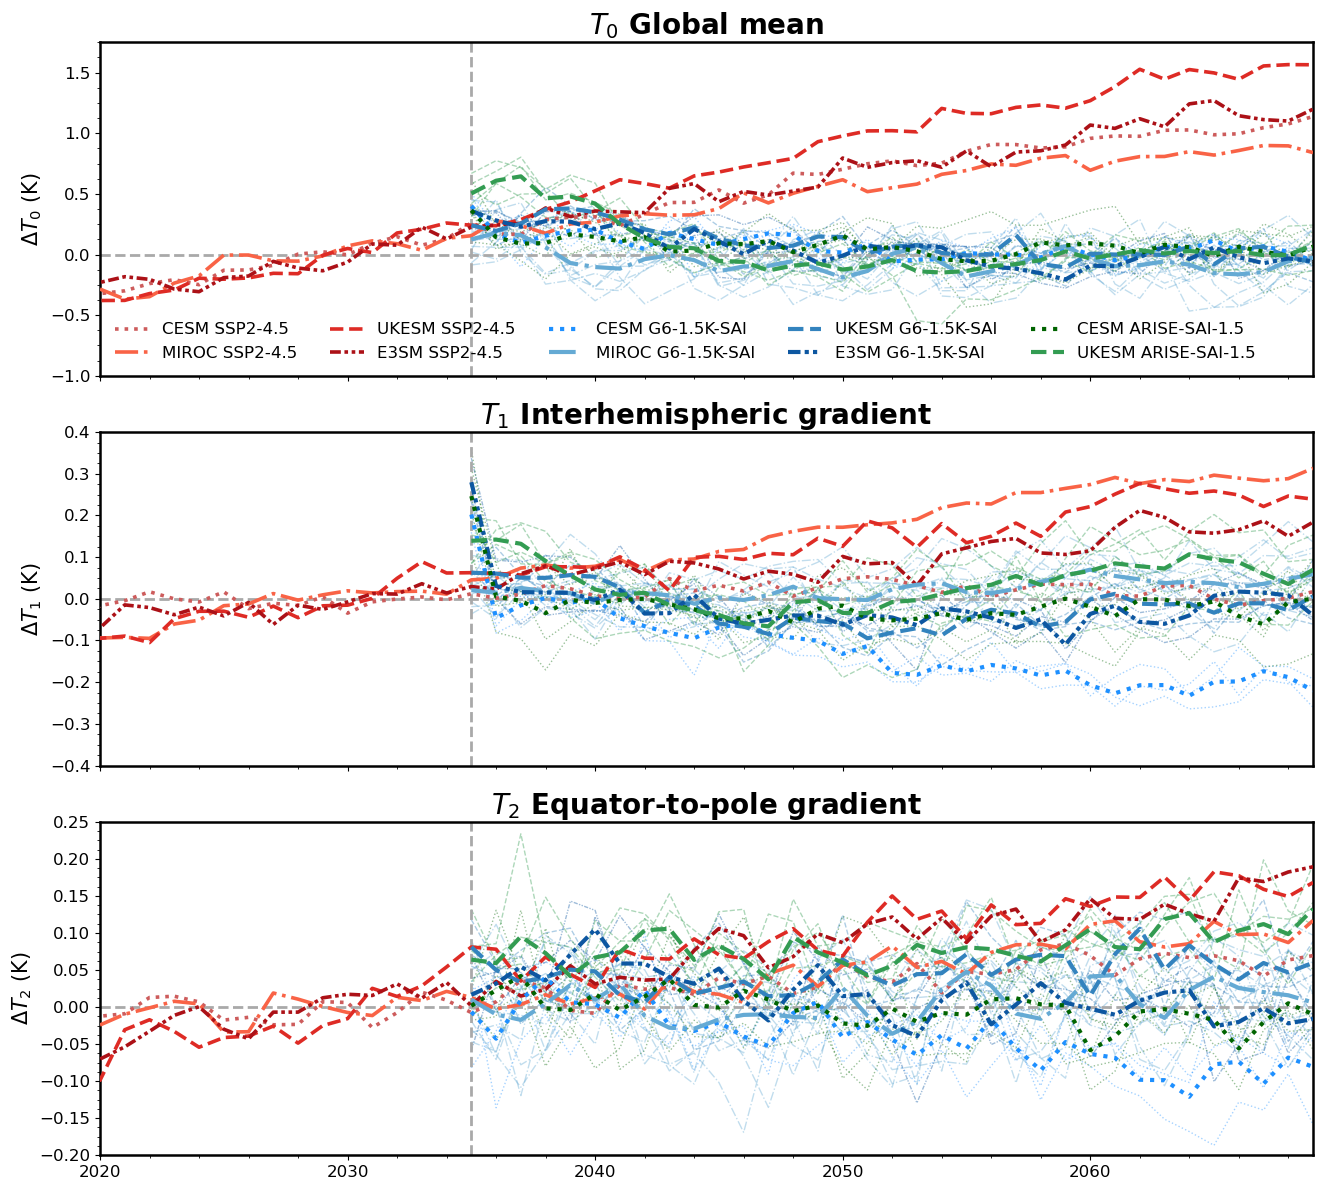

In [64]:
# Plot: 3 subplots (T0, T1, T2)
# - SSP: ensemble mean only (bold), per model w/ different linestyle
# - G6/ARISE: faint members + bold ensemble mean, per model shade
# - Legend only on first subplot
# ============================================================
fig, axs = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
which_list = ["T0", "T1", "T2"]
titles = {
    "T0": r"$T_0$ Global mean",
    "T1": r"$T_1$ Interhemispheric gradient",
    "T2": r"$T_2$ Equator-to-pole gradient",
}
ylabels = {"T0": r"$\Delta T_0$ (K)", "T1": r"$\Delta T_1$ (K)", "T2": r"$\Delta T_2$ (K)"}

for ax, which in zip(axs, which_list):
    # SSP ensemble mean only, each model distinct linestyle & red shade
    for m in MODEL_ORDER:
        if m not in coeff or "SSP2-4.5" not in coeff[m]:
            continue
        series = coeff[m]["SSP2-4.5"][which] - ssp_base[m][which]  # (year, ensemble) or (year, ...)
        if "ensemble" in series.dims:
            series_mean = series.mean("ensemble")
        else:
            series_mean = series

        ax.plot(
            series_mean["year"], series_mean,
            color=SSP_COLORS[m], linestyle=LINESTYLE[m], linewidth=2.6,
            label=f"{m} SSP2-4.5" if which == "T0" else None,
            zorder=3
        )

    # G6: members faint + mean bold
    for m in MODEL_ORDER:
        if m not in coeff or "G6-1.5K-SAI" not in coeff[m]:
            continue
        series = coeff[m]["G6-1.5K-SAI"][which] - ssp_base[m][which]  # relative to SSP baseline
        if "ensemble" in series.dims:
            for e in series["ensemble"].values:
                ax.plot(series["year"], series.sel(ensemble=e),
                        color=G6_COLORS[m], linestyle=LINESTYLE[m],
                        linewidth=1.0, alpha=0.4, zorder=1)
            ax.plot(series["year"], series.mean("ensemble"),
                    color=G6_COLORS[m], linestyle=LINESTYLE[m],
                    linewidth=3.0,
                    label=f"{m} G6-1.5K-SAI" if which == "T0" else None,
                    zorder=4)
        else:
            ax.plot(series["year"], series,
                    color=G6_COLORS[m], linestyle=LINESTYLE[m],
                    linewidth=3.0,
                    label=f"{m} G6-1.5K-SAI" if which == "T0" else None,
                    zorder=4)

    # ARISE: members faint + mean bold (baseline differs for UKESM)
    for m in MODEL_ORDER:
        if m not in coeff or "ARISE-SAI-1.5" not in coeff[m]:
            continue
        series = coeff[m]["ARISE-SAI-1.5"][which] - arise_base[m][which]
        if "ensemble" in series.dims:
            for e in series["ensemble"].values:
                ax.plot(series["year"], series.sel(ensemble=e),
                        color=ARISE_COLORS[m], linestyle=LINESTYLE[m],
                        linewidth=1.0, alpha=0.4, zorder=1)
            ax.plot(series["year"], series.mean("ensemble"),
                    color=ARISE_COLORS[m], linestyle=LINESTYLE[m],
                    linewidth=3.0,
                    label=f"{m} ARISE-SAI-1.5" if which == "T0" else None,
                    zorder=5)
        else:
            ax.plot(series["year"], series,
                    color=ARISE_COLORS[m], linestyle=LINESTYLE[m],
                    linewidth=3.0,
                    label=f"{m} ARISE-SAI-1.5" if which == "T0" else None,
                    zorder=5)

    _style(ax, titles[which], ylabels[which])

# Legend only on first subplot
axs[0].legend(ncol=5, fontsize=12, frameon=False, loc="lower left") #frameon=False
axs[0].set_ylim([-1.0,1.75])
axs[1].set_ylim([-0.4,0.4])
axs[2].set_ylim([-0.2,0.25])
for ax in axs:
    ax.set_xlim(2020, 2069)
    ax.tick_params(axis='both', which='major', labelsize=12)
    
plt.tight_layout()
plt.savefig("./fig/temp_all_model.png", bbox_inches="tight")

plt.show()
